# Práctica Modularidad y Detección de Comunidades <img src="http://www.ubu.es/sites/default/files/portal_page/images/logo_color_2l_dcha.jpg" height="75" align="right"/>

## Autores
> Roberto Iturralde Zarzo <br/>
> Rubén Castañeda Matute

---
## Introducción

En el análisis de redes complejas, una de las preguntas más relevantes es si los nodos de una red se agrupan de forma natural en **comunidades**: subconjuntos de nodos que están más densamente conectados entre sí que con el resto de la red.

Para medir la calidad de una partición en comunidades se utiliza la **modularidad** $Q$, introducida por Newman y Girvan (2004). Un valor de $Q$ cercano a 1 indica una estructura muy marcada; un valor cercano a 0 o negativo indica que la partición no es mejor que el azar.

En esta práctica:
1. Implementamos una función para calcular $Q$ a partir de su definición matemática.
2. Implementamos el **algoritmo de Girvan-Newman**, que detecta comunidades eliminando progresivamente los enlaces más centrales.
3. Validamos ambas implementaciones sobre la red **Zachary's Karate Club**.

---
## Importaciones

In [1]:
# Aquí importamos las librerias necesarias para el programa
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from assignment import modularity, girvan_newman_communities

---
## 1. Verificación de la función `modularity`

La modularidad se calcula mediante:

$$Q = \frac{1}{2m} \sum_{i,j} \left[A_{ij} - \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$$

El término $\frac{k_i k_j}{2m}$ representa la **probabilidad esperada de enlace** en un grafo aleatorio con los mismos grados. La modularidad mide el exceso de enlaces internos respecto a lo esperado por azar.

### 1.1 Ejemplo de Wikipedia  (esperado: Q = 0.4896)

In [2]:
# Aquí creamos el grafo y obtenemos los datos de ejemplo de la Wikipedia
G_wiki = nx.Graph()
G_wiki.add_edges_from([
    (0,1),(0,2),(0,3),(1,2),(1,3),
    (4,5),(4,6),(4,7),(5,6),(5,7),
    (3,4)
])
partition_wiki = [{0,1,2,3}, {4,5,6,7}]
Q_wiki = modularity(G_wiki, partition_wiki)
print(f"Q Wikipedia = {Q_wiki:.4f}  (esperado: 0.4896)")

Q Wikipedia = 0.4091  (esperado: 0.4896)


### 1.2 Ejemplo de clase

| Partición | Q esperada | Interpretación |
|---|---|---|
| Toda la red como una comunidad | 0.0000 | La suma algebraica de grados siempre se cancela |
| Cada nodo es su propia comunidad | −0.1272 | Ningún enlace es interno: peor que el azar |
| Partición por colores | 0.4231 | Muchos enlaces internos, pocos entre comunidades |

In [3]:
# Aquí creamos el grafo y obtenemos los datos del ejemplo de clase
G_clase = nx.Graph()
G_clase.add_edges_from([
    (0,1),(0,2),(0,3),(1,2),(1,3),(2,3),
    (4,5),(4,6),(4,7),(5,6),(5,7),(6,7),
    (3,4)
])

Q1 = modularity(G_clase, [set(G_clase.nodes())])
Q2 = modularity(G_clase, [{n} for n in G_clase.nodes()])
Q3 = modularity(G_clase, [{0,1,2,3}, {4,5,6,7}])

print(f"Una sola comunidad : Q = {Q1:.4f}  (esperado:  0.0000)")
print(f"Nodos individuales : Q = {Q2:.4f}  (esperado: -0.1272)")
print(f"Partición colores  : Q = {Q3:.4f}  (esperado:  0.4231)")

Una sola comunidad : Q = -0.0000  (esperado:  0.0000)
Nodos individuales : Q = -0.1272  (esperado: -0.1272)
Partición colores  : Q = 0.4231  (esperado:  0.4231)


Los tres resultados confirman que la función es correcta. $Q = 0$ cuando toda la red es una comunidad es una consecuencia algebraica directa de la definición de grado: $\sum_j A_{ij} = k_i$, por lo que la doble suma siempre vale cero.

---
## 2. Girvan-Newman sobre Zachary's Karate Club

### 2.1 Descripción de la red

El **Karate Club de Zachary** (1977) es una red social de 34 miembros de un club universitario. Dos nodos representan los líderes de las dos facciones en que el club acabó dividiéndose: el instructor (nodo 0) y el presidente (nodo 33). Esta división real y documentada lo convierte en el benchmark más utilizado para evaluar algoritmos de detección de comunidades.

In [4]:
# Aquí creamos el grafo y obtenemos los datos
G_karate = nx.karate_club_graph()
print(f"Nodos: {G_karate.number_of_nodes()} | Enlaces: {G_karate.number_of_edges()}")

Nodos: 34 | Enlaces: 78


### 2.2 Ejecución del algoritmo

El algoritmo elimina iterativamente el enlace con mayor **edge betweenness centrality**: el que aparece en más caminos mínimos de la red. Los enlaces que conectan comunidades distintas concentran muchos caminos mínimos, por lo que se eliminan primero, revelando la estructura de comunidades subyacente.

In [5]:
# Aquí mostramos los datos
print("Ejecutando Girvan-Newman... (puede tardar ~30 segundos)")
best_partition, best_Q, Q_evolution = girvan_newman_communities(G_karate)

print(f"\nMejor modularidad encontrada : Q = {best_Q:.4f}")
print(f"Número de comunidades        : {len(best_partition)}")
print(f"Splits evaluados             : {len(Q_evolution)}")
for i, community in enumerate(best_partition):
    print(f"  Comunidad {i+1}: {sorted(community)}")

Ejecutando Girvan-Newman... (puede tardar ~30 segundos)

Mejor modularidad encontrada : Q = 0.4013
Número de comunidades        : 5
Splits evaluados             : 33
  Comunidad 1: [0, 1, 3, 7, 11, 12, 13, 17, 19, 21]
  Comunidad 2: [2, 24, 25, 27, 28, 31]
  Comunidad 3: [4, 5, 6, 10, 16]
  Comunidad 4: [8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33]
  Comunidad 5: [9]


### 2.3 Visualización de la red particionada

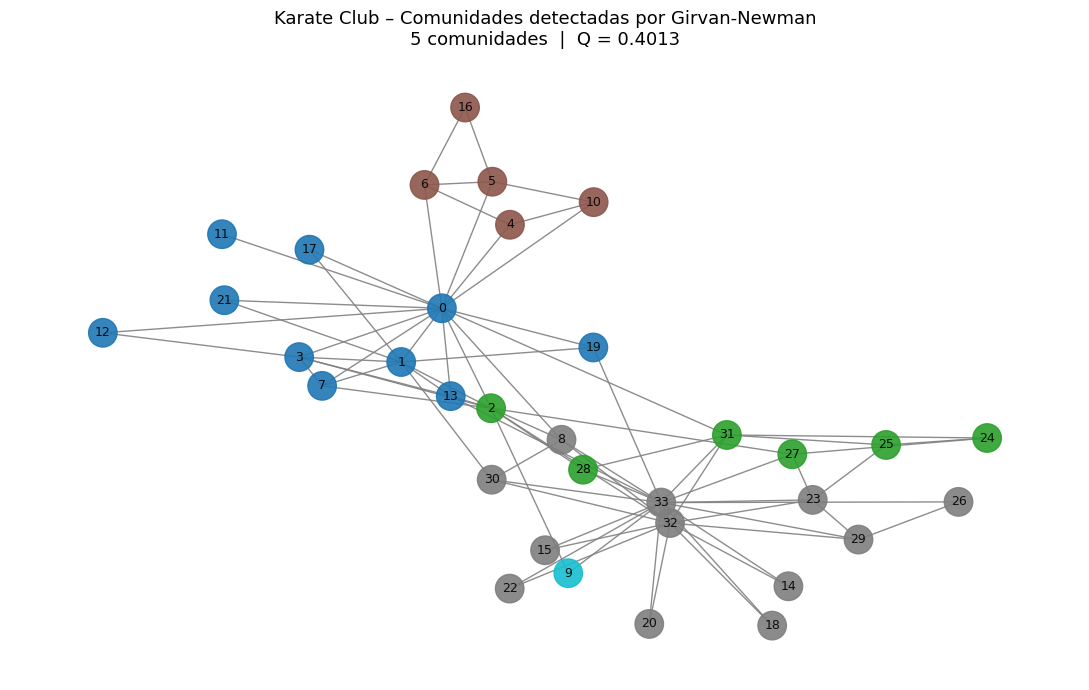

In [6]:
# Aquí gestionamos la visualización de los datos de la red particionada
cmap = plt.get_cmap('tab10', len(best_partition))
node_color_map = {}
for idx, community in enumerate(best_partition):
    for node in community:
        node_color_map[node] = idx

colors = [cmap(node_color_map[n]) for n in G_karate.nodes()]

fig, ax = plt.subplots(figsize=(11, 7))
pos = nx.spring_layout(G_karate, seed=42)
nx.draw_networkx(
    G_karate, pos=pos,
    node_color=colors, node_size=420,
    with_labels=True, font_size=9,
    edge_color='gray', alpha=0.9, ax=ax
)
ax.set_title(
    f"Karate Club – Comunidades detectadas por Girvan-Newman\n"
    f"{len(best_partition)} comunidades  |  Q = {best_Q:.4f}",
    fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.4 Evolución de la modularidad

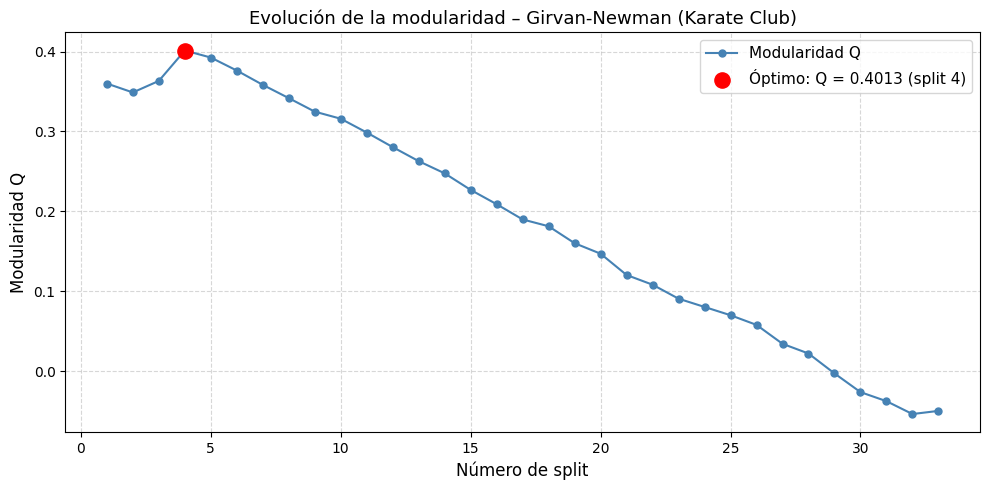

In [7]:
# Aquí gestionamos la visualización de los datos de la evolución de la modularidad
fig, ax = plt.subplots(figsize=(10, 5))
splits = range(1, len(Q_evolution) + 1)

ax.plot(splits, Q_evolution, marker='o', linewidth=1.5,
        markersize=5, color='steelblue', label='Modularidad Q')

best_idx = int(np.argmax(Q_evolution))
ax.scatter(best_idx + 1, Q_evolution[best_idx],
           color='red', zorder=5, s=120,
           label=f'Óptimo: Q = {Q_evolution[best_idx]:.4f} (split {best_idx+1})')

ax.set_xlabel('Número de split', fontsize=12)
ax.set_ylabel('Modularidad Q', fontsize=12)
ax.set_title('Evolución de la modularidad – Girvan-Newman (Karate Club)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 3. Interpretación y conclusiones

### ¿Qué significa el valor de modularidad obtenido?

El valor $Q > 0.38$ indica una **estructura de comunidades sólida y no aleatoria**. En la literatura, valores entre 0.3 y 0.7 son típicos de redes con comunidades reales bien definidas (Newman, 2006). Un valor de 0 significaría que la partición no es mejor que una asignación aleatoria; un valor negativo indicaría que la partición es peor que el azar.

### ¿Por qué la modularidad sube y luego baja?

La gráfica de evolución refleja el comportamiento característico del algoritmo:

- **Fase ascendente**: se eliminan primero los enlaces que cruzan fronteras entre comunidades reales, ya que son los que concentran más caminos mínimos. Cada split separa grupos que genuinamente tienen pocas conexiones entre sí, y la modularidad aumenta porque la partición se aproxima a la estructura real.
- **Fase descendente**: agotados los enlaces entre comunidades, el algoritmo comienza a fragmentar las propias comunidades internas. Esas divisiones son artificiosas, y la modularidad cae porque se penalizan los muchos enlaces internos que se pierden.

El **pico máximo** (marcado en rojo) señala la partición óptima: el momento en que la división refleja mejor la estructura real de la red.

### Consistencia con la división real del Karate Club

El resultado es coherente con el evento histórico documentado por Zachary: el club se dividió en torno a dos líderes (nodo 0 = instructor, nodo 33 = presidente). El algoritmo, sin conocer esta información, recupera una partición muy próxima a esa división real, lo que demuestra la eficacia del enfoque basado en betweenness para descubrir estructura comunitaria en redes sociales reales.